In [ ]:
!pip install huggingface_hub -q


In [ ]:
from huggingface_hub import login
login(token="ADD YOUR HF TOKEN")


In [ ]:
!git clone https://github.com/facebookresearch/sam-3d-body.git
%cd sam-3d-body


Cloning into 'sam-3d-body'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 184 (delta 38), reused 14 (delta 14), pack-reused 70 (from 1)
Receiving objects: 100% (184/184), 22.39 MiB | 26.54 MiB/s, done.
Resolving deltas: 100% (40/40), done.
/content/sam-3d-body


In [ ]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -e .
!pip install 'git+https://github.com/facebookresearch/detectron2.git'
!pip install git+https://github.com/microsoft/MoGe.git


Looking in indexes: https://download.pytorch.org/whl/cu121
Obtaining file:///content/sam-3d-body
ERROR: file:///content/sam-3d-body does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-5o1h63pv
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-5o1h63pv
  Resolved https://github.com/facebookresearch/detectron2.git to commit 8a9d885b3d4dcf1bef015f0593b872ed8d32b4ab
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from huggingface_hub import snapshot_download

repo_id = "facebook/sam-3d-body-dinov3"
local_dir = "checkpoints/sam-3d-body-dinov3"

snapshot_download(repo_id=repo_id, local_dir=local_dir, local_dir_use_symlinks=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'/content/sam-3d-body/checkpoints/sam-3d-body-dinov3'

In [ ]:
from google.colab import files
uploaded = files.upload()  # a file picker dialog will pop up


Saving sam3dsample.png to sam3dsample.png


In [ ]:
import cv2
import numpy as np
from notebook.utils import setup_sam_3d_body
from tools.vis_utils import visualize_sample_together

# Load model
estimator = setup_sam_3d_body(hf_repo_id="facebook/sam-3d-body-dinov3")

# Run on your image
img_bgr = cv2.imread("sam3dsample.png")  # replace with your filename
outputs = estimator.process_one_image(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

# Visualize and save
rend_img = visualize_sample_together(img_bgr, outputs, estimator.faces)
cv2.imwrite("output.png", rend_img.astype(np.uint8))


Loading SAM 3D Body model from facebook/sam-3d-body-dinov3...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading SAM 3D Body model...
Downloading: "https://github.com/facebookresearch/dinov3/zipball/main" to /root/.cache/torch/hub/main.zip



missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.parameter_transform, head_pose.mhr.character_torch.parameter_transform.pose_parameters, head_pose.mhr.character_torch.parameter_transform.rigid_parameters, head_pose.mhr.char

Loading human detector from vitdet...
########### Using human detector: ViTDet...


...

model.pt:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓
####### Please make sure the input image is in RGB format
Running object detector...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0309 16:28:45.924000 451 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Found boxes: [[ 48.63624   22.170406 367.33392  418.40335 ]]
Running FOV estimator ...


True

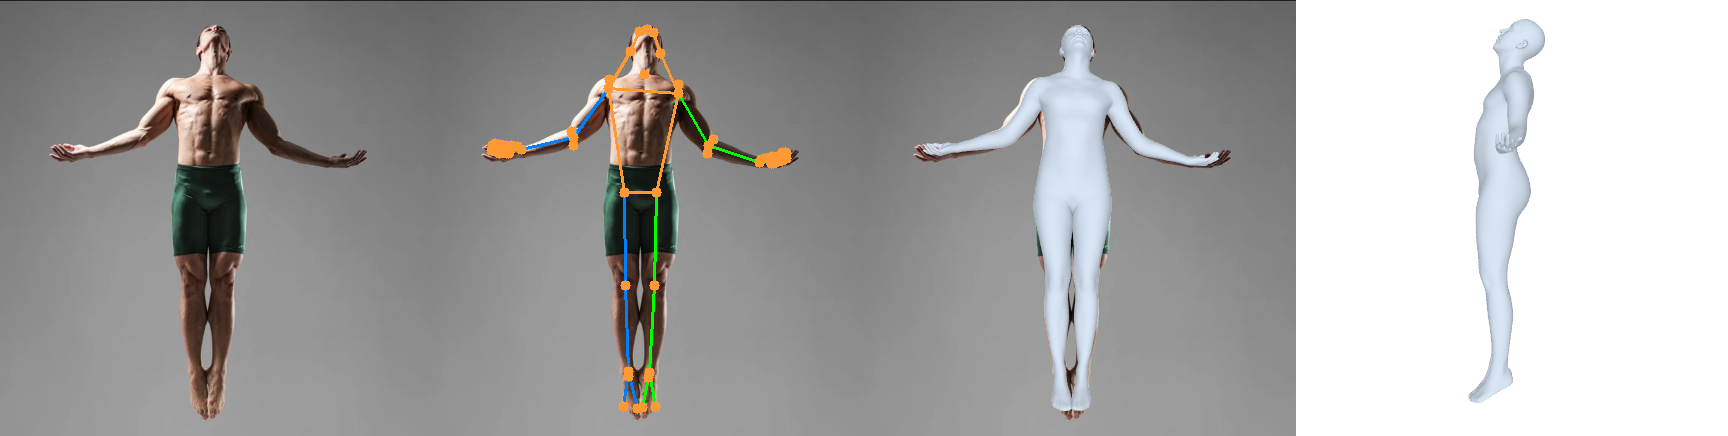

In [ ]:
from IPython.display import Image
Image("output.png")


In [ ]:
import cv2
import numpy as np
from notebook.utils import setup_sam_3d_body
from tools.vis_utils import visualize_sample_together

# Set up the estimator
estimator = setup_sam_3d_body(hf_repo_id="facebook/sam-3d-body-dinov3")

# Load and process image
img_bgr = cv2.imread("sam3dsample.png")
outputs = estimator.process_one_image(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

# Visualize and save results
rend_img = visualize_sample_together(img_bgr, outputs, estimator.faces)
cv2.imwrite("output.jpg", rend_img.astype(np.uint8))

Loading SAM 3D Body model from facebook/sam-3d-body-dinov3...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading SAM 3D Body model...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main

missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.parameter_transform, head_pose.mhr.character_torch.parameter_transform.pose_parameters, head_pose.mhr

Loading human detector from vitdet...
########### Using human detector: ViTDet...
Loading FOV estimator from moge2...
########### Using fov estimator: MoGe2...
Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓
####### Please make sure the input image is in RGB format
Running object detector...
Found boxes: [[ 48.63624   22.170406 367.33392  418.40335 ]]
Running FOV estimator ...


True

In [ ]:
import os
# See what files are in the current directory
print(os.listdir('/content/sam-3d-body'))


['assets', 'demo.py', '.gitignore', 'notebook', 'CONTRIBUTING.md', 'sam3dsample.png', 'data', 'README.md', 'LICENSE', '.git', 'output.png', 'tools', 'CODE_OF_CONDUCT.md', 'sam_3d_body', 'checkpoints', 'INSTALL.md']


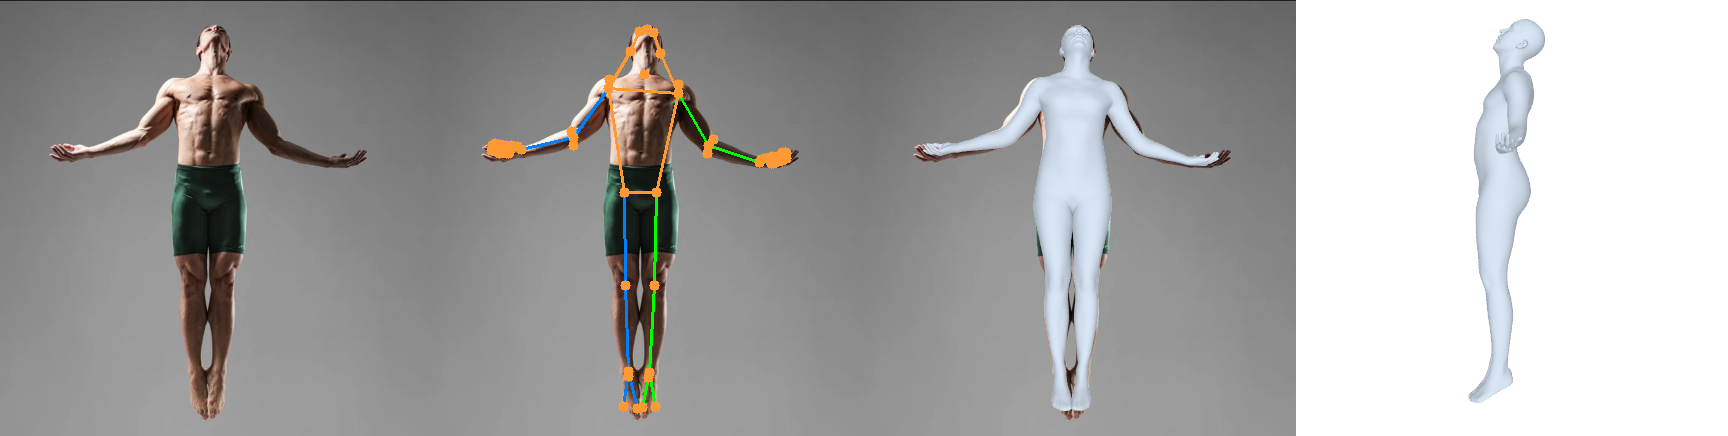

In [ ]:
from IPython.display import Image
Image("output.png")


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sample2.png to sample2.png


In [ ]:
import cv2
import numpy as np
from notebook.utils import setup_sam_3d_body
from tools.vis_utils import visualize_sample_together

# Set up the estimator
estimator = setup_sam_3d_body(hf_repo_id="facebook/sam-3d-body-dinov3")

# Load and process image
img_bgr = cv2.imread("sample2.png")
outputs = estimator.process_one_image(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

# Visualize and save results
rend_img = visualize_sample_together(img_bgr, outputs, estimator.faces)
cv2.imwrite("output2.jpg", rend_img.astype(np.uint8))

Loading SAM 3D Body model from facebook/sam-3d-body-dinov3...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading SAM 3D Body model...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main

missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.parameter_transform, head_pose.mhr.character_torch.parameter_transform.pose_parameters, head_pose.mhr

Loading human detector from vitdet...
########### Using human detector: ViTDet...
Loading FOV estimator from moge2...
########### Using fov estimator: MoGe2...
Mask-condition inference is not supported...
Setup complete!
  Human detector: ✓
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✓
####### Please make sure the input image is in RGB format
Running object detector...
Found boxes: [[ 44.549515  32.351944 255.36024  362.8416  ]]
Running FOV estimator ...


True

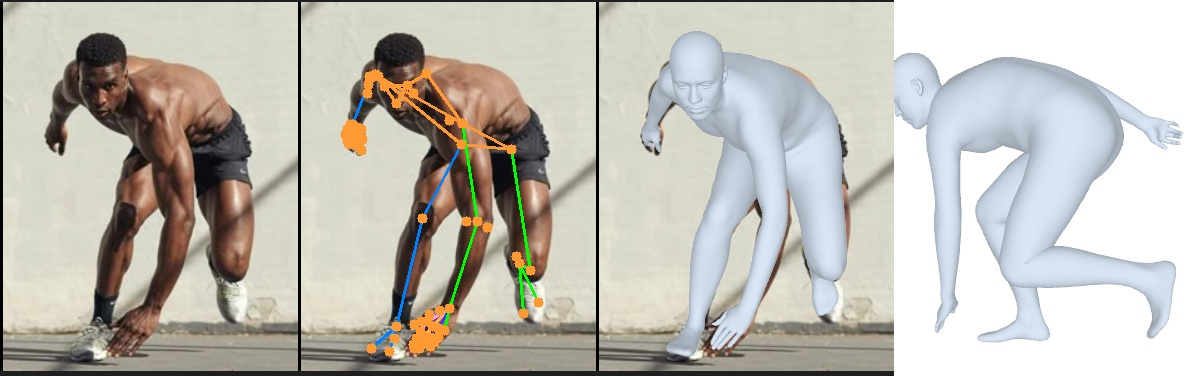

In [ ]:
from IPython.display import Image
Image("output2.jpg")
